In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

plt.rcParams['figure.dpi'] = 120

from ml.config import SpinupConfig, ConvergenceConfig
from ml.data.sweep_file import SweepFile
from ml.data.isca_segment import read_segments
from ml.diagnostics.enstrophy import mean_enstrophy
from ml.diagnostics.spinup import find_spinup_time
from ml.diagnostics.convergence import find_zonal_mean_convergence_time, compute_time_mean_zonal_mean

EXPERIMENT_DIR  = Path('../../output/barotropic_stirring-T85')

SPINUP_CFG      = SpinupConfig(z_threshold=2.0, stable_time=3, window_size=10)
CONVERGENCE_CFG = ConvergenceConfig(threshold=0.05, hold=3)

sweep = SweepFile.from_experiment_dir(EXPERIMENT_DIR)

print(f"{'code':<10} config")
print('-' * 50)
for code in sweep.codes():
    print(f"{code:<10} {sweep.describe(code)}")

code       config
--------------------------------------------------
6cc1bd     lat0=30.0
fc0e25     lat0=45.0


In [14]:
SELECTED_CODES = sweep.codes()

In [15]:
def _load_profile(sim_dir: Path) -> tuple[np.ndarray, np.ndarray, int | None]:
    ds  = read_segments(str(sim_dir / 'run*/atmos_daily.nc'))
    vor = ds.vor.values
    u   = ds.ucomp.values
    lat = ds.lat.values
    M   = vor.shape[0]
    t_s = find_spinup_time(mean_enstrophy(vor, lat), **SPINUP_CFG.to_kwargs())
    t_c = find_zonal_mean_convergence_time(u, lat, t_s or 0, **CONVERGENCE_CFG.to_kwargs())
    start = t_c if t_c is not None else (t_s or 0)
    profile = compute_time_mean_zonal_mean(u, start, M)
    ds.close()
    return lat, profile, t_c


def _plot_code(code: str, profiles: np.ndarray, latitudes: np.ndarray, t_cs: list, ax):
    mean_profile = profiles.mean(axis=0)
    std_profile  = profiles.std(axis=0)
    params = sweep.params_for(code)
    lat0   = params['stirring_lat0'] if params else None
    jet_lat = latitudes[np.argmax(np.abs(mean_profile))]
    valid_t_cs = [t for t in t_cs if t is not None]
    mean_t_c = np.mean(valid_t_cs) if valid_t_cs else float('nan')

    for profile in profiles:
        ax.plot(profile, latitudes, color='tab:blue', alpha=0.08, linewidth=0.8)
    ax.fill_betweenx(latitudes, mean_profile - std_profile, mean_profile + std_profile,
                     color='gray', alpha=0.35, label='mean +/- std')
    ax.plot(mean_profile, latitudes, color='tab:orange', linewidth=2, label='mean')
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    if lat0 is not None:
        ax.axhline(lat0,    color='tab:red',   linewidth=1.2, linestyle='--', label=f'lat0={lat0}')
    ax.axhline(jet_lat, color='tab:green', linewidth=1.2, linestyle='--', label=f'jet={jet_lat:.1f}')
    ax.set_xlabel('zonal-mean zonal wind [m/s]')
    ax.set_ylabel('latitude [deg]')
    ax.set_ylim(-90, 90)
    ax.set_title(f'{sweep.describe(code)}  [{code}]\nconv={mean_t_c:.1f} days  std={std_profile.mean():.3f}')
    ax.legend(fontsize=7)


def plot_noise_floor(codes: list[str], ncols: int = 3):
    nrows = -(-len(codes) // ncols)

    jobs = [(code, d)
            for code in codes
            for d in sorted(
                (EXPERIMENT_DIR / 'simulations').glob(code + '-*'),
                key=lambda p: p.name,
            )
            if list(d.glob('run*/atmos_daily.nc'))]

    raw = {code: [] for code in codes}
    for code, d in tqdm(jobs, desc='loading'):
        lat, profile, t_c = _load_profile(d)
        raw[code].append((lat, profile, t_c))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
    axes_flat = np.array(axes).flat

    for code, ax in zip(codes, axes_flat):
        latitudes = raw[code][0][0]
        profiles  = np.stack([r[1] for r in raw[code]])
        t_cs      = [r[2] for r in raw[code]]
        _plot_code(code, profiles, latitudes, t_cs, ax)

    for ax in list(axes_flat)[len(codes):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

    # std bar chart
    labels = [sweep.describe(c) for c in codes]
    stds   = [np.stack([r[1] for r in raw[c]]).std(axis=0).mean() for c in codes]
    fig2, ax2 = plt.subplots(figsize=(len(codes) * 1.5, 4))
    ax2.bar(labels, stds, color='tab:blue')
    ax2.set_ylabel('mean std of climatology profiles')
    ax2.set_title('within-config noise floor per parameter config')
    plt.tight_layout()
    plt.show()

loading:   0%|          | 0/60 [00:00<?, ?it/s]

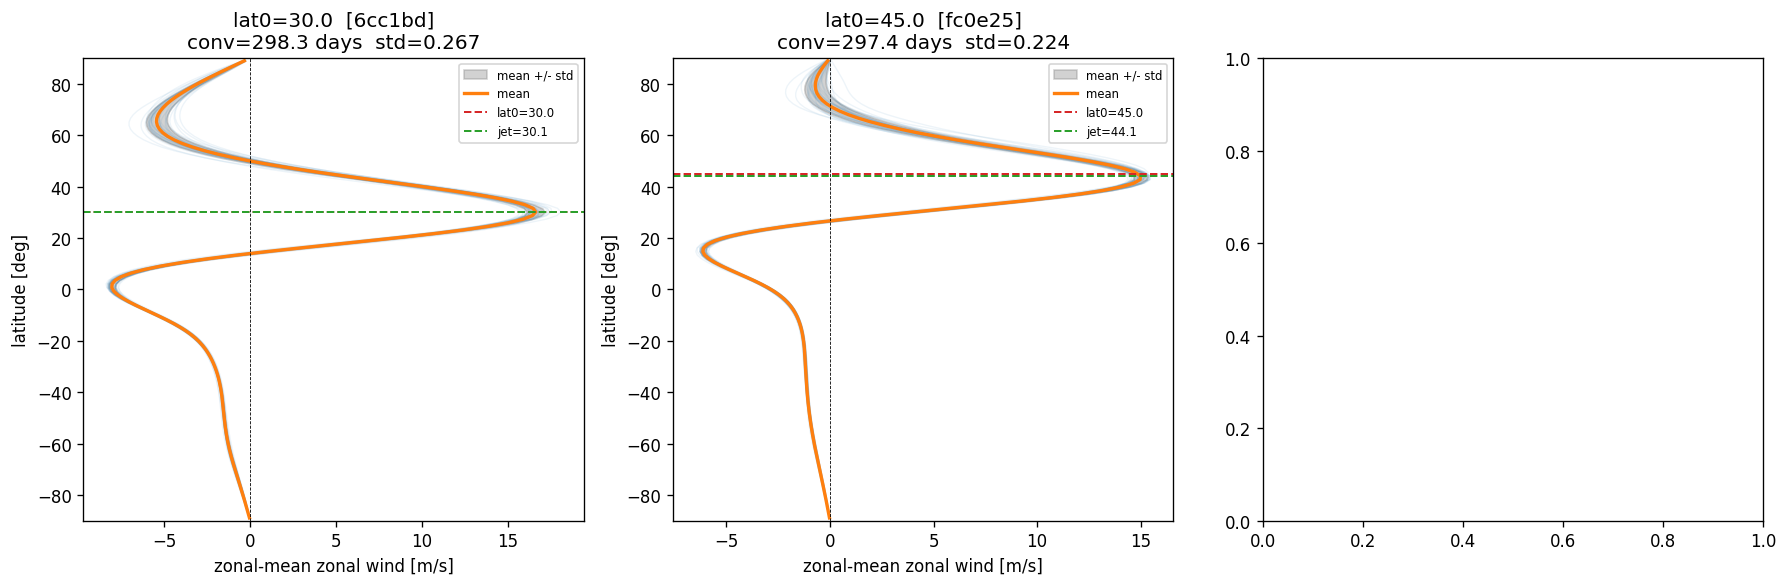

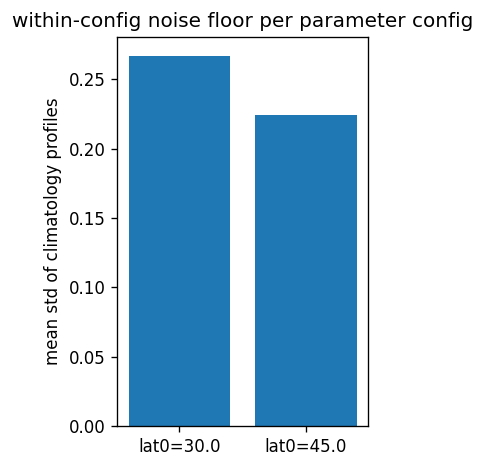

In [16]:
plot_noise_floor(SELECTED_CODES)